In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
folder_path = '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/real-world-experiment-data/'
eit_file = f'{folder_path}eit-3.csv'
optitrack_file = f'{folder_path}optitrack-3.csv'
output_file = f'{folder_path}eit-optitrack-merged-3.csv'

In [25]:
# Read the CSV files, specifying the first column as the header
eit_df = pd.read_csv(eit_file, header=None)
optitrack_df = pd.read_csv(optitrack_file, header=None)

print(eit_df.head())
print(optitrack_df.head())

       0       1        2        3        4        5        6        7   \
0  22.162  61.499  193.782  157.208  177.546  156.015  166.896  163.922   
1  22.213  61.686  192.531  157.208  177.546  155.574  166.484  163.576   
2  22.260  63.393  192.531  156.907  177.291  155.461  166.253  163.375   
3  22.413  63.423  192.151  156.551  176.876  154.978  165.818  163.030   
4  22.490  64.151  192.033  156.454  176.753  154.978  165.818  162.919   

        8        9        10  
0  210.639  376.626  627.254  
1  210.220  375.033  627.278  
2  209.707  375.248  623.110  
3  208.807  376.003  621.029  
4  208.597  373.543  627.327  
        0          1          2
0  22.150 -54.959526 -62.676803
1  22.158 -54.995746 -62.637329
2  22.167 -54.994670 -62.575897
3  22.175 -55.120092 -62.459305
4  22.183 -55.172809 -62.438782


In [26]:
# Name the columns
eit_df.columns = ['timestamp'] + [f'eit_{i}' for i in range(10)]
optitrack_df.columns = ['timestamp', 'x', 'y']

print(eit_df.head())
print(optitrack_df.head())

   timestamp   eit_0    eit_1    eit_2    eit_3    eit_4    eit_5    eit_6  \
0     22.162  61.499  193.782  157.208  177.546  156.015  166.896  163.922   
1     22.213  61.686  192.531  157.208  177.546  155.574  166.484  163.576   
2     22.260  63.393  192.531  156.907  177.291  155.461  166.253  163.375   
3     22.413  63.423  192.151  156.551  176.876  154.978  165.818  163.030   
4     22.490  64.151  192.033  156.454  176.753  154.978  165.818  162.919   

     eit_7    eit_8    eit_9  
0  210.639  376.626  627.254  
1  210.220  375.033  627.278  
2  209.707  375.248  623.110  
3  208.807  376.003  621.029  
4  208.597  373.543  627.327  
   timestamp          x          y
0     22.150 -54.959526 -62.676803
1     22.158 -54.995746 -62.637329
2     22.167 -54.994670 -62.575897
3     22.175 -55.120092 -62.459305
4     22.183 -55.172809 -62.438782


In [30]:
# Full Outer Join
merged_df = eit_df.merge(optitrack_df, on='timestamp', how='outer')
merged_df = merged_df.sort_values(by='timestamp')

print(merged_df.head(n=20))

    timestamp   eit_0    eit_1    eit_2    eit_3    eit_4    eit_5    eit_6  \
0      22.150     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1      22.158     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2      22.162  61.499  193.782  157.208  177.546  156.015  166.896  163.922   
3      22.167     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4      22.175     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
5      22.183     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
6      22.192     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
7      22.200     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
8      22.208     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
9      22.213  61.686  192.531  157.208  177.546  155.574  166.484  163.576   
10     22.217     NaN      NaN      NaN      NaN      NaN      NaN      NaN   
11     22.225     NaN      NaN      NaN      NaN    

In [31]:
df_interpolated = merged_df.interpolate(method='linear')
print(df_interpolated.head())

   timestamp      eit_0       eit_1    eit_2    eit_3    eit_4       eit_5  \
0     22.150        NaN         NaN      NaN      NaN      NaN         NaN   
1     22.158        NaN         NaN      NaN      NaN      NaN         NaN   
2     22.162  61.499000  193.782000  157.208  177.546  156.015  166.896000   
3     22.167  61.525714  193.603286  157.208  177.546  155.952  166.837143   
4     22.175  61.552429  193.424571  157.208  177.546  155.889  166.778286   

        eit_6       eit_7       eit_8       eit_9          x          y  
0         NaN         NaN         NaN         NaN -54.959526 -62.676803  
1         NaN         NaN         NaN         NaN -54.995746 -62.637329  
2  163.922000  210.639000  376.626000  627.254000 -54.995208 -62.606613  
3  163.872571  210.579143  376.398429  627.257429 -54.994670 -62.575897  
4  163.823143  210.519286  376.170857  627.260857 -55.120092 -62.459305  


In [32]:
df_cleaned = df_interpolated.dropna()
print(df_cleaned.head())

   timestamp      eit_0       eit_1    eit_2    eit_3    eit_4       eit_5  \
2     22.162  61.499000  193.782000  157.208  177.546  156.015  166.896000   
3     22.167  61.525714  193.603286  157.208  177.546  155.952  166.837143   
4     22.175  61.552429  193.424571  157.208  177.546  155.889  166.778286   
5     22.183  61.579143  193.245857  157.208  177.546  155.826  166.719429   
6     22.192  61.605857  193.067143  157.208  177.546  155.763  166.660571   

        eit_6       eit_7       eit_8       eit_9          x          y  
2  163.922000  210.639000  376.626000  627.254000 -54.995208 -62.606613  
3  163.872571  210.579143  376.398429  627.257429 -54.994670 -62.575897  
4  163.823143  210.519286  376.170857  627.260857 -55.120092 -62.459305  
5  163.773714  210.459429  375.943286  627.264286 -55.172809 -62.438782  
6  163.724286  210.399571  375.715714  627.267714 -55.272728 -62.365646  


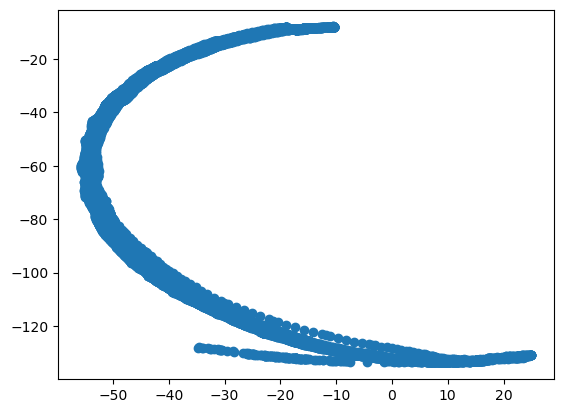

In [36]:
xs = df_cleaned['x']
ys = df_cleaned['y']
plt.figure()
plt.scatter(xs, ys)

In [ ]:
filtered_df = df_cleaned[df_cleaned['timestamp'].isin(eit_df['timestamp'])]

print(filtered_df.head())

    timestamp   eit_0    eit_1    eit_2    eit_3    eit_4    eit_5    eit_6  \
2      22.162  61.499  193.782  157.208  177.546  156.015  166.896  163.922   
9      22.213  61.686  192.531  157.208  177.546  155.574  166.484  163.576   
16     22.260  63.393  192.531  156.907  177.291  155.461  166.253  163.375   
35     22.413  63.423  192.151  156.551  176.876  154.978  165.818  163.030   
45     22.490  64.151  192.033  156.454  176.753  154.978  165.818  162.919   

      eit_7    eit_8    eit_9          x          y  
2   210.639  376.626  627.254 -54.995208 -62.606613  
9   210.220  375.033  627.278 -55.454600 -62.204407  
16  209.707  375.248  623.110 -55.640129 -61.273255  
35  208.807  376.003  621.029 -55.081978 -55.813621  
45  208.597  373.543  627.327 -54.824713 -52.110153  


In [39]:
df_reset = filtered_df.reset_index(drop=True)

print(df_reset.head())
print(len(df_reset))

   timestamp   eit_0    eit_1    eit_2    eit_3    eit_4    eit_5    eit_6  \
0     22.162  61.499  193.782  157.208  177.546  156.015  166.896  163.922   
1     22.213  61.686  192.531  157.208  177.546  155.574  166.484  163.576   
2     22.260  63.393  192.531  156.907  177.291  155.461  166.253  163.375   
3     22.413  63.423  192.151  156.551  176.876  154.978  165.818  163.030   
4     22.490  64.151  192.033  156.454  176.753  154.978  165.818  162.919   

     eit_7    eit_8    eit_9          x          y  
0  210.639  376.626  627.254 -54.995208 -62.606613  
1  210.220  375.033  627.278 -55.454600 -62.204407  
2  209.707  375.248  623.110 -55.640129 -61.273255  
3  208.807  376.003  621.029 -55.081978 -55.813621  
4  208.597  373.543  627.327 -54.824713 -52.110153  
1139


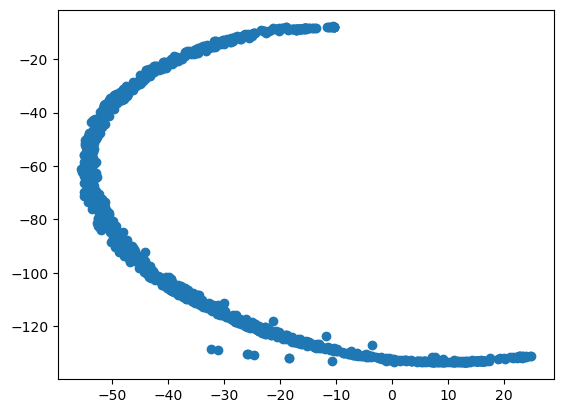

In [40]:
xs = df_reset['x']
ys = df_reset['y']
plt.figure()
plt.scatter(xs, ys)

In [41]:
df_reset.to_csv(f'{folder_path}my-merged-3.csv', index=False, header=False)